In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.metrics import r2_score

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.boston_housing.load_data()

# For easier column-based operations, convert the feature arrays to pandas DataFrames
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

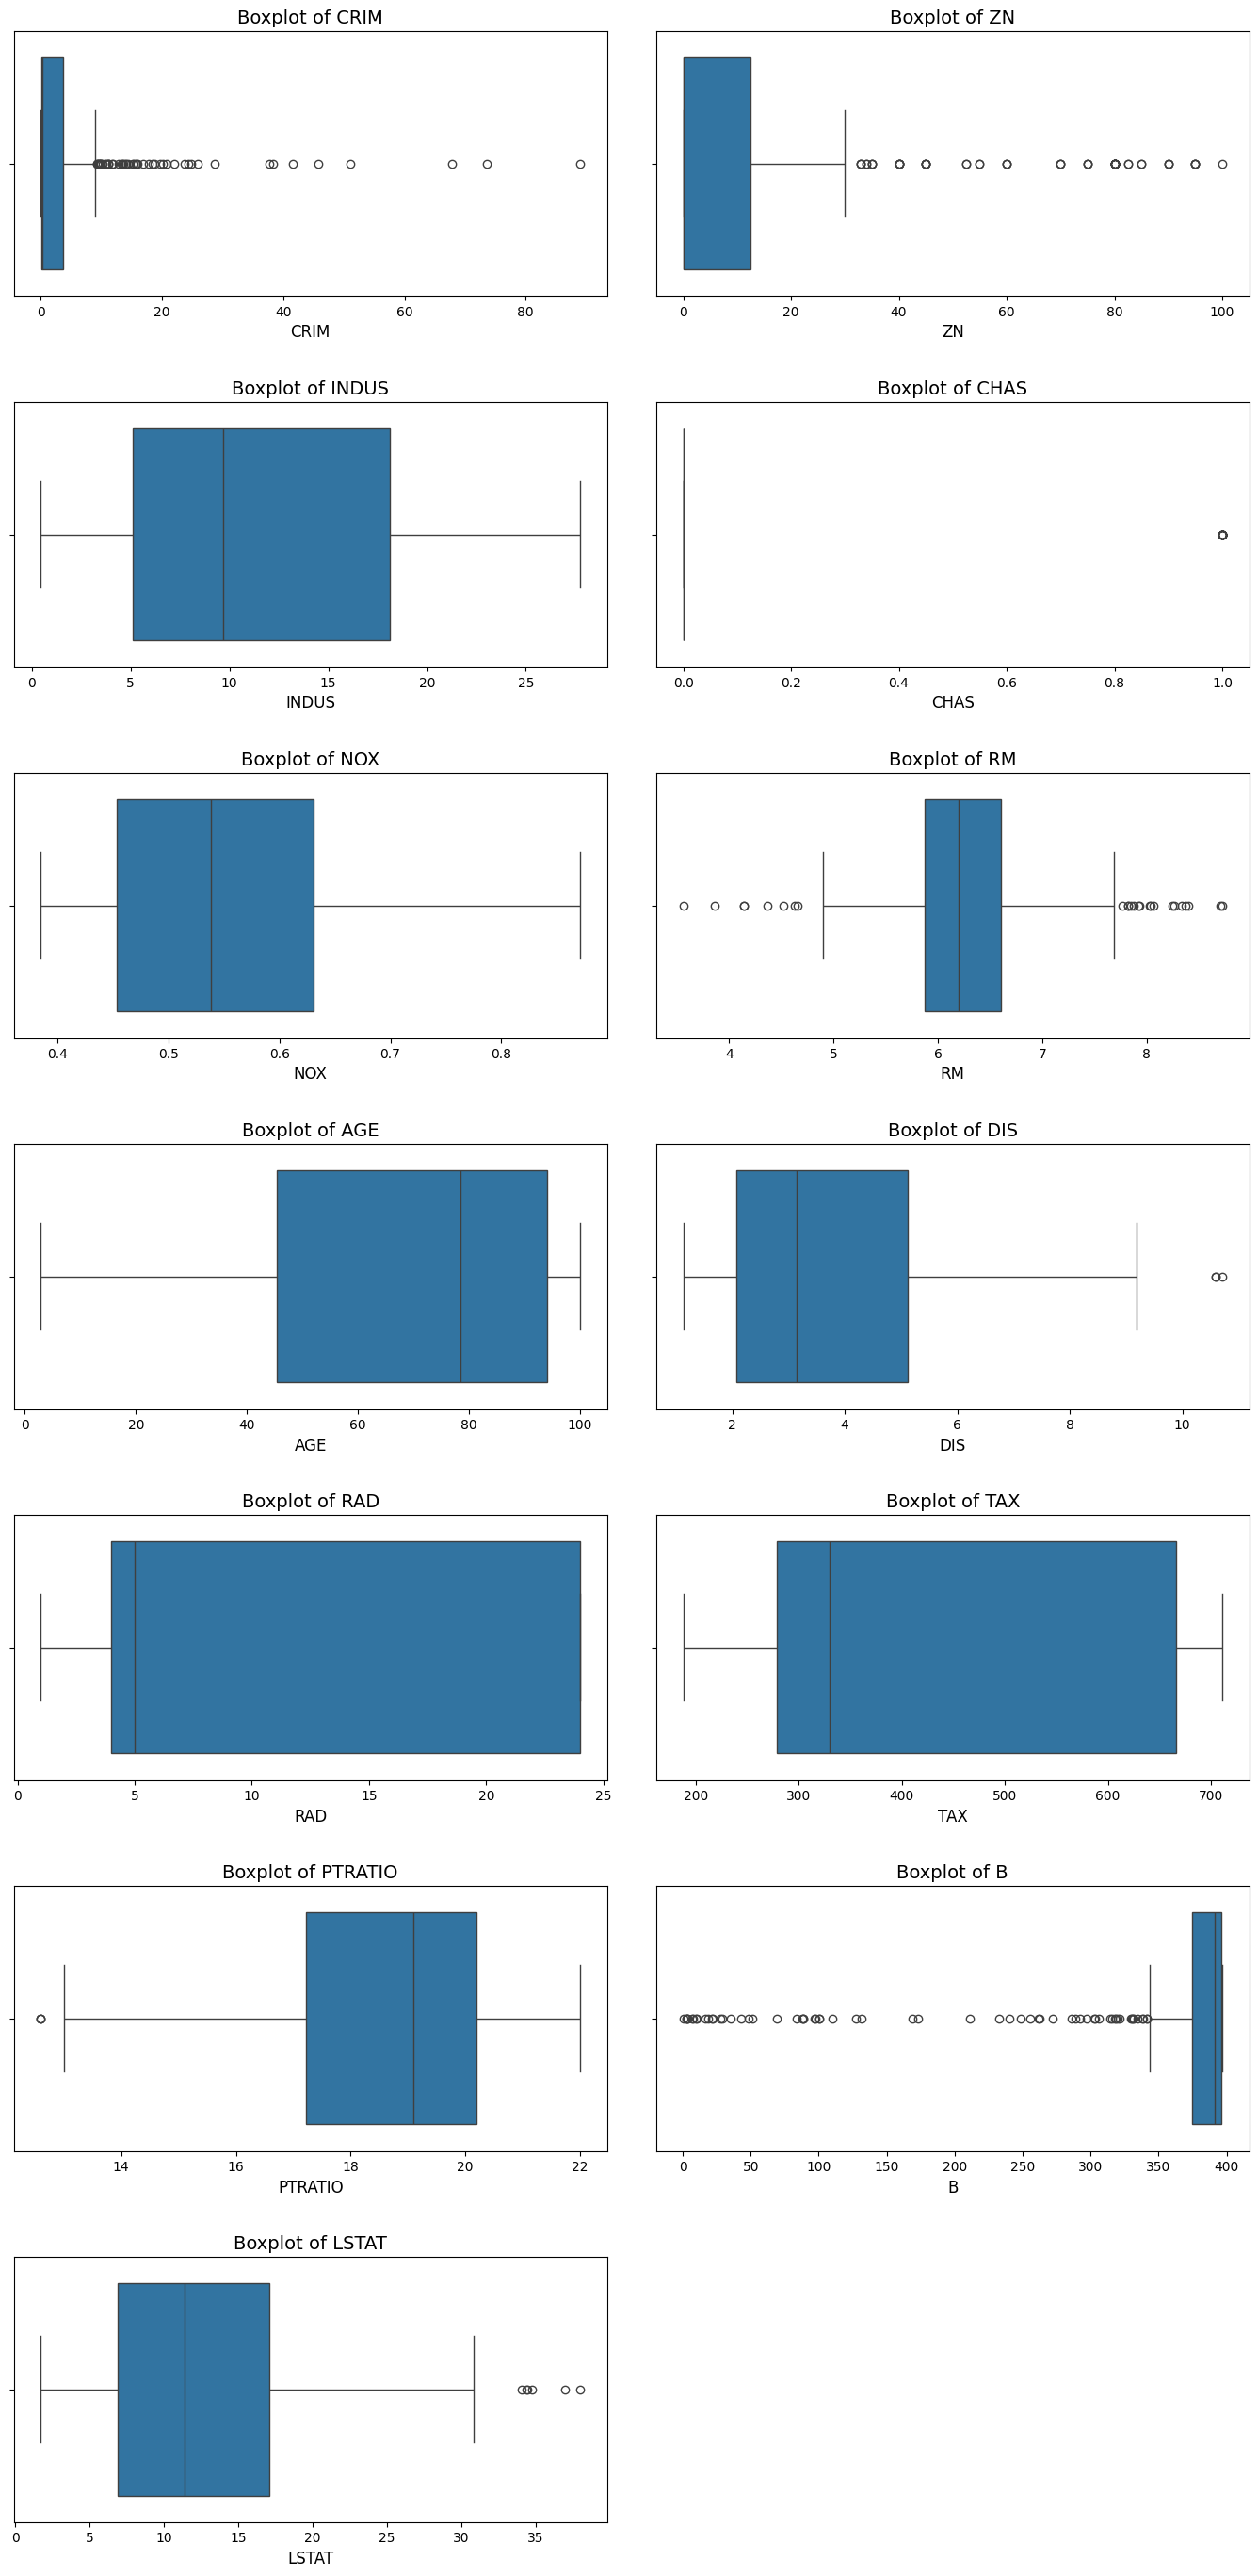

In [3]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(14, 4 * 7))
axes = axes.flatten()
for i, feat in enumerate(X_train.columns):
    ax = axes[i]
    sns.boxplot(data=X_train, x=feat, ax=ax)
    ax.set_title(f'Boxplot of {feat}', fontsize=14)
    ax.set_xlabel(feat, fontsize=12)

for i in range(len(X_train.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0)

plt.show()

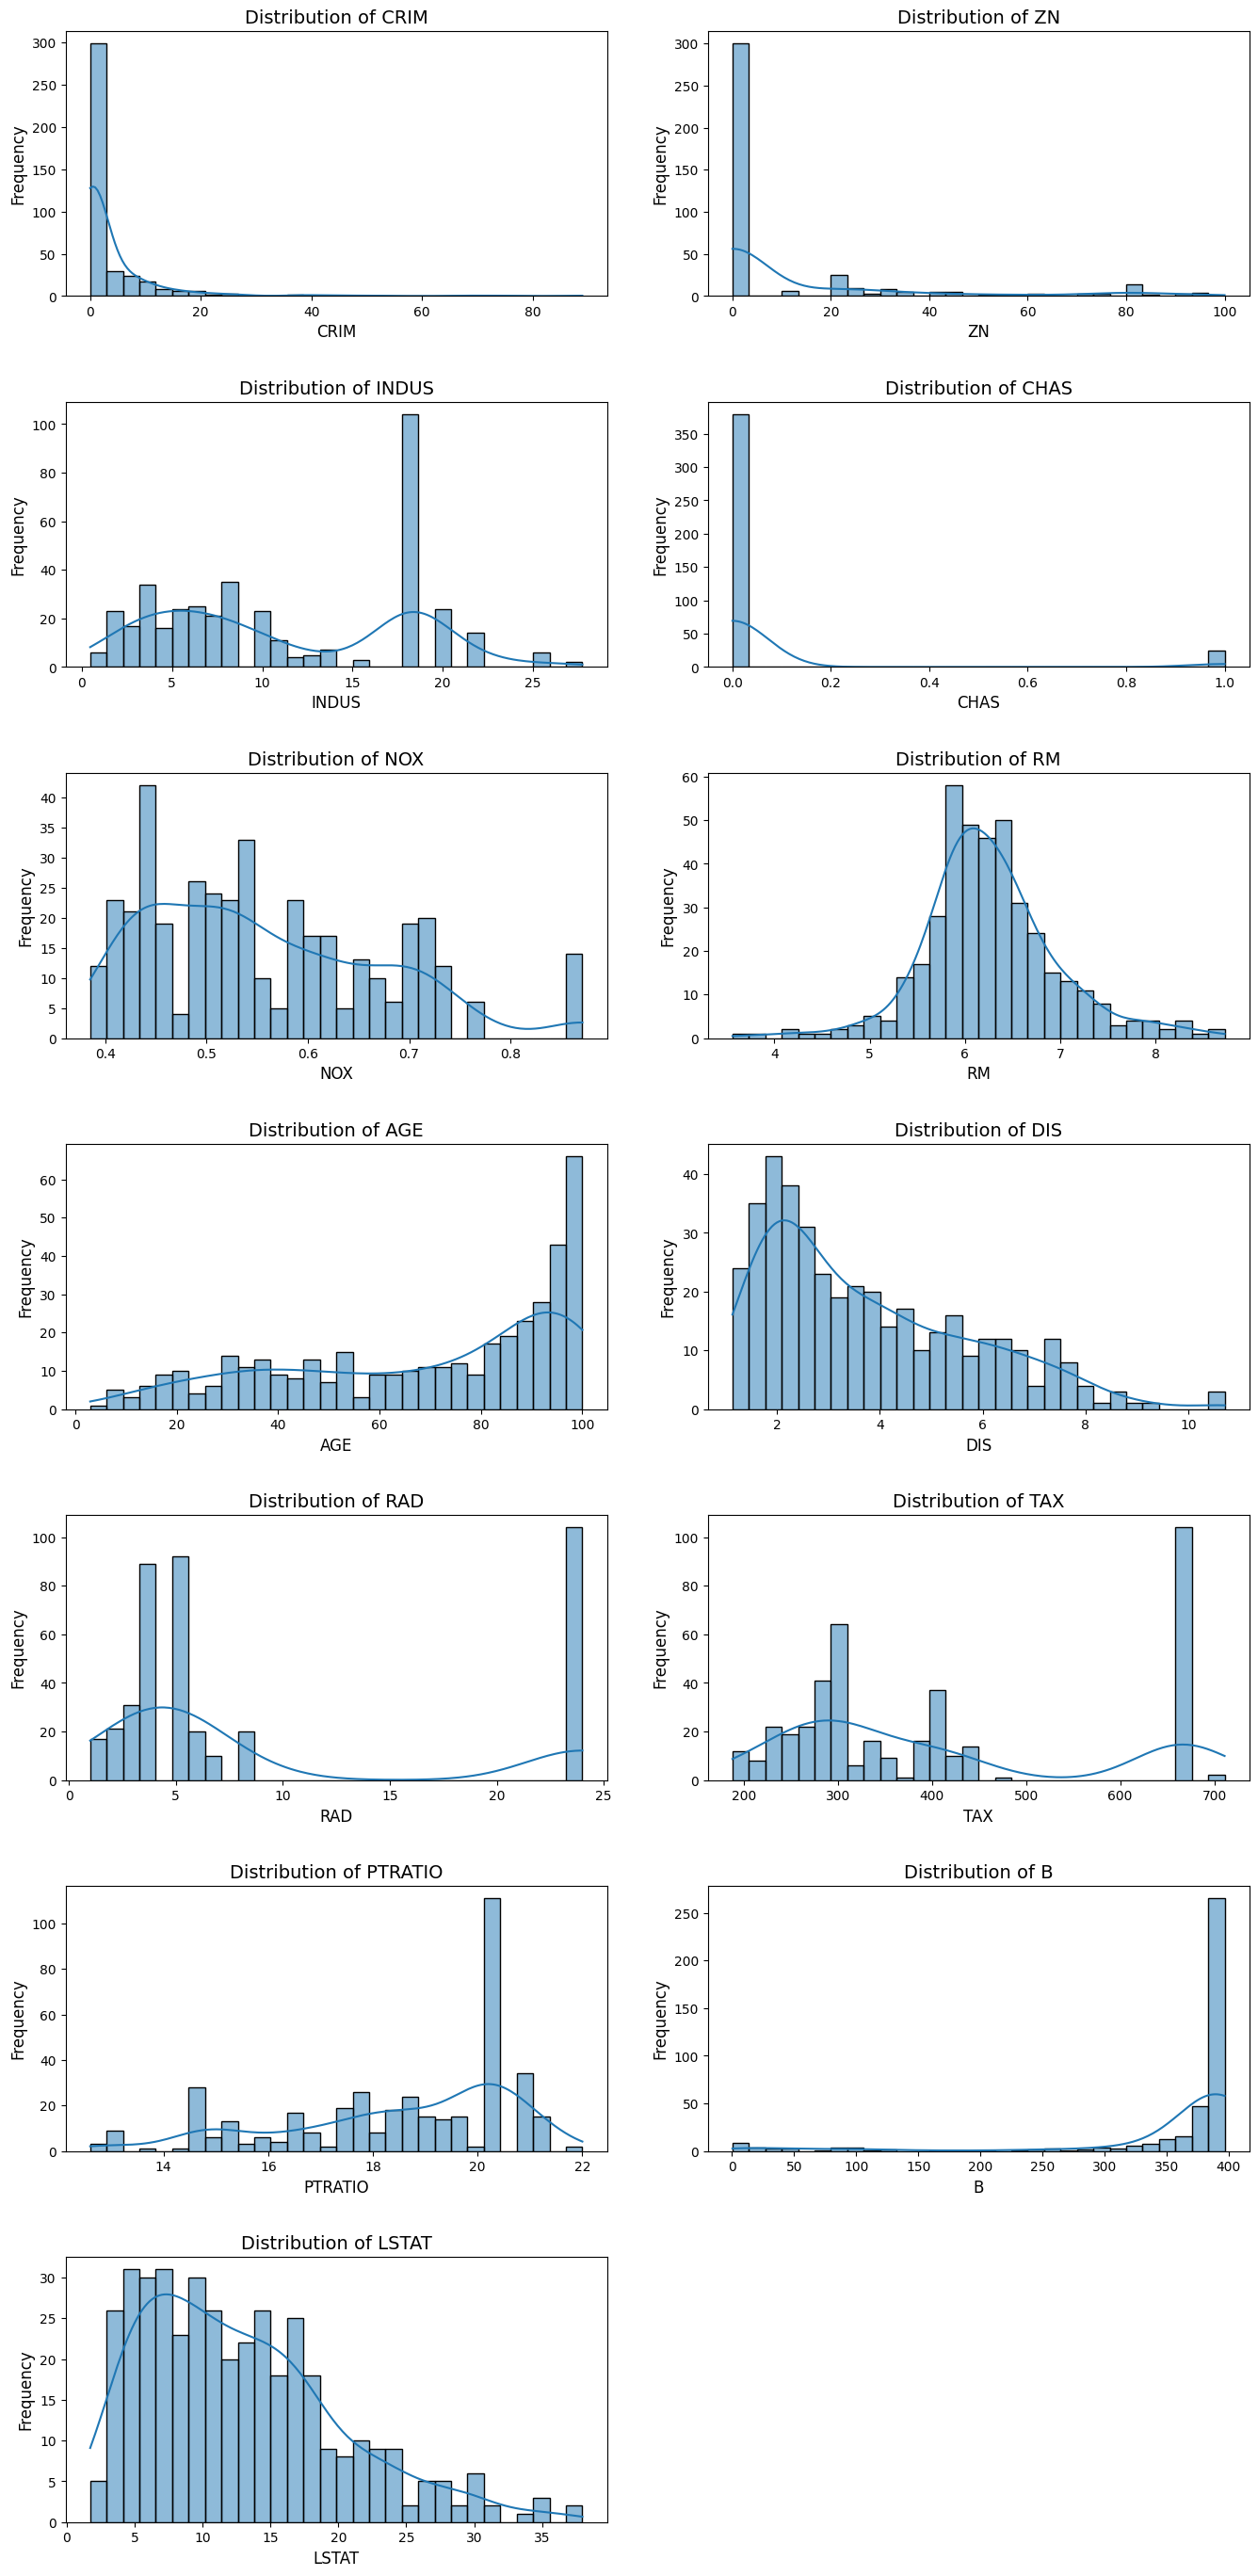

In [4]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(14, 4 * 7))
axes = axes.flatten()
for i, feat in enumerate(X_train.columns):
    ax = axes[i]
    sns.histplot(data=X_train, x=feat, bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feat}', fontsize=14)
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)

for i in range(len(X_train.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0)

plt.show()

In [5]:
# for feat in X_train.columns:
#     percentile99 = X_train[feat].quantile(0.99)
#     percentile1 = X_train[feat].quantile(0.01)

#     X_train[feat] = np.where(X_train[feat] > percentile99, percentile99, X_train[feat])
#     X_train[feat] = np.where(X_train[feat] < percentile1, percentile1, X_train[feat])

#     X_test[feat] = np.where(X_test[feat] > percentile99, percentile99, X_test[feat])
#     X_test[feat] = np.where(X_test[feat] < percentile1, percentile1, X_test[feat])


qt = QuantileTransformer(output_distribution='normal', n_quantiles=X_train.shape[0])
qt.fit(X_train)
X_train_scaled = pd.DataFrame(qt.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(qt.transform(X_test), columns=X_test.columns, index=X_test.index)

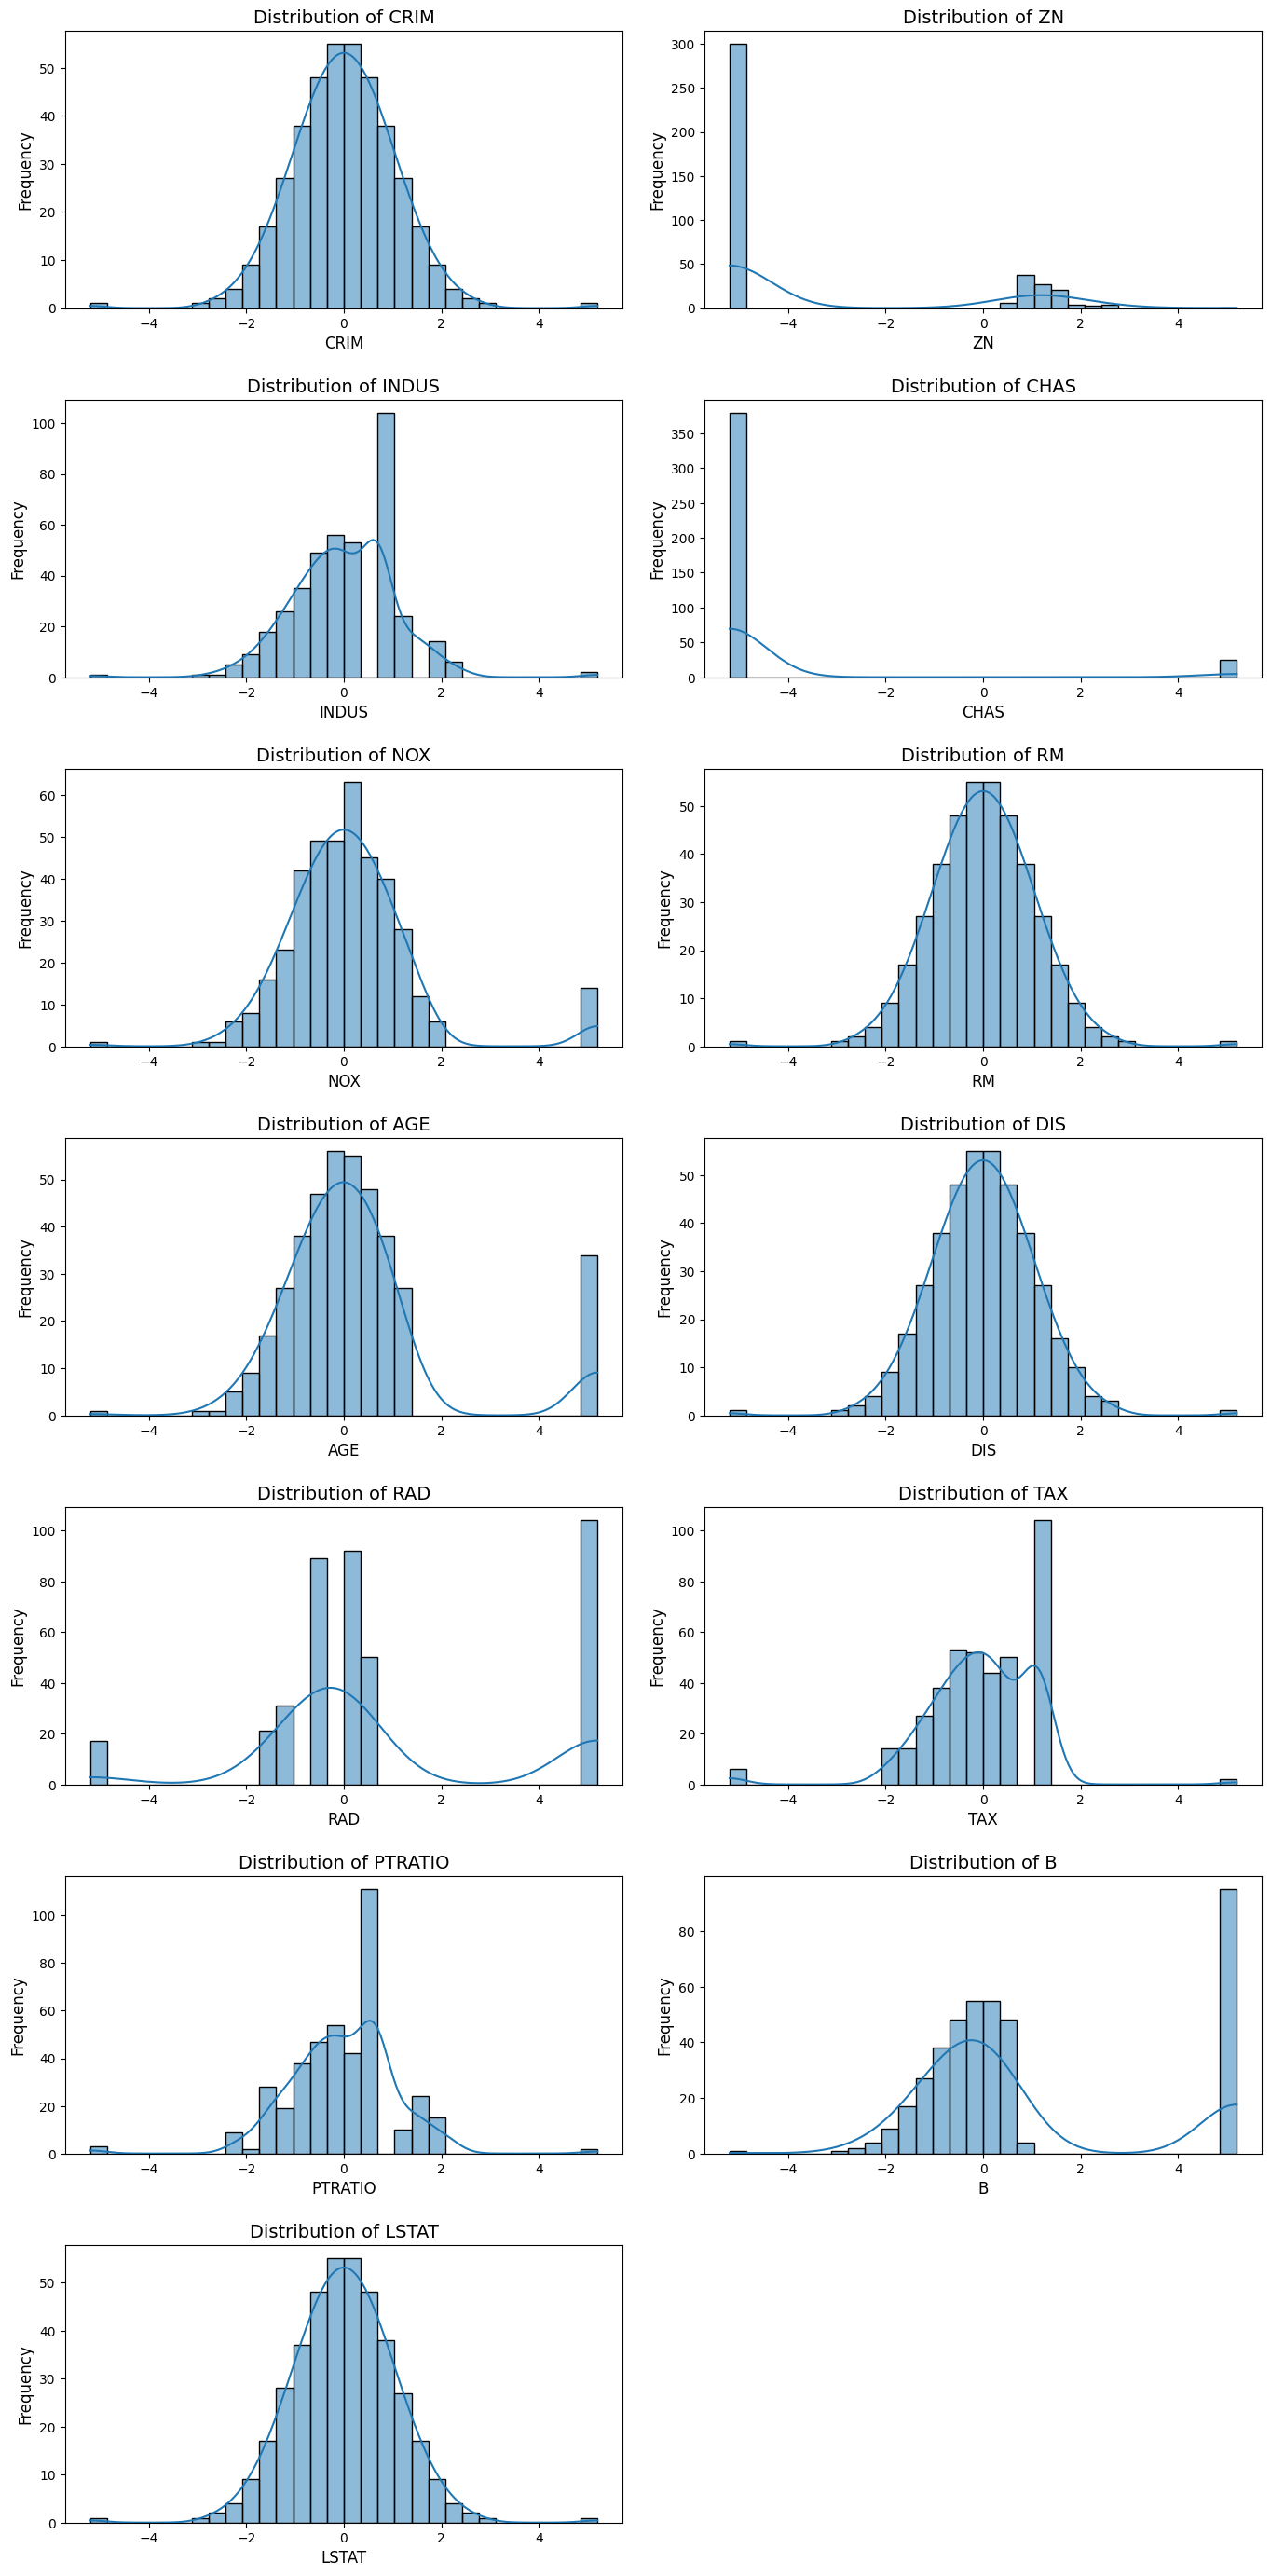

In [6]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(14, 4 * 7))
axes = axes.flatten()

for i, feat in enumerate(X_train_scaled.columns):
    ax = axes[i]
    sns.histplot(data=X_train_scaled, x=feat, bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feat}', fontsize=14)
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)

for i in range(len(X_train_scaled.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=2.0)
plt.show()

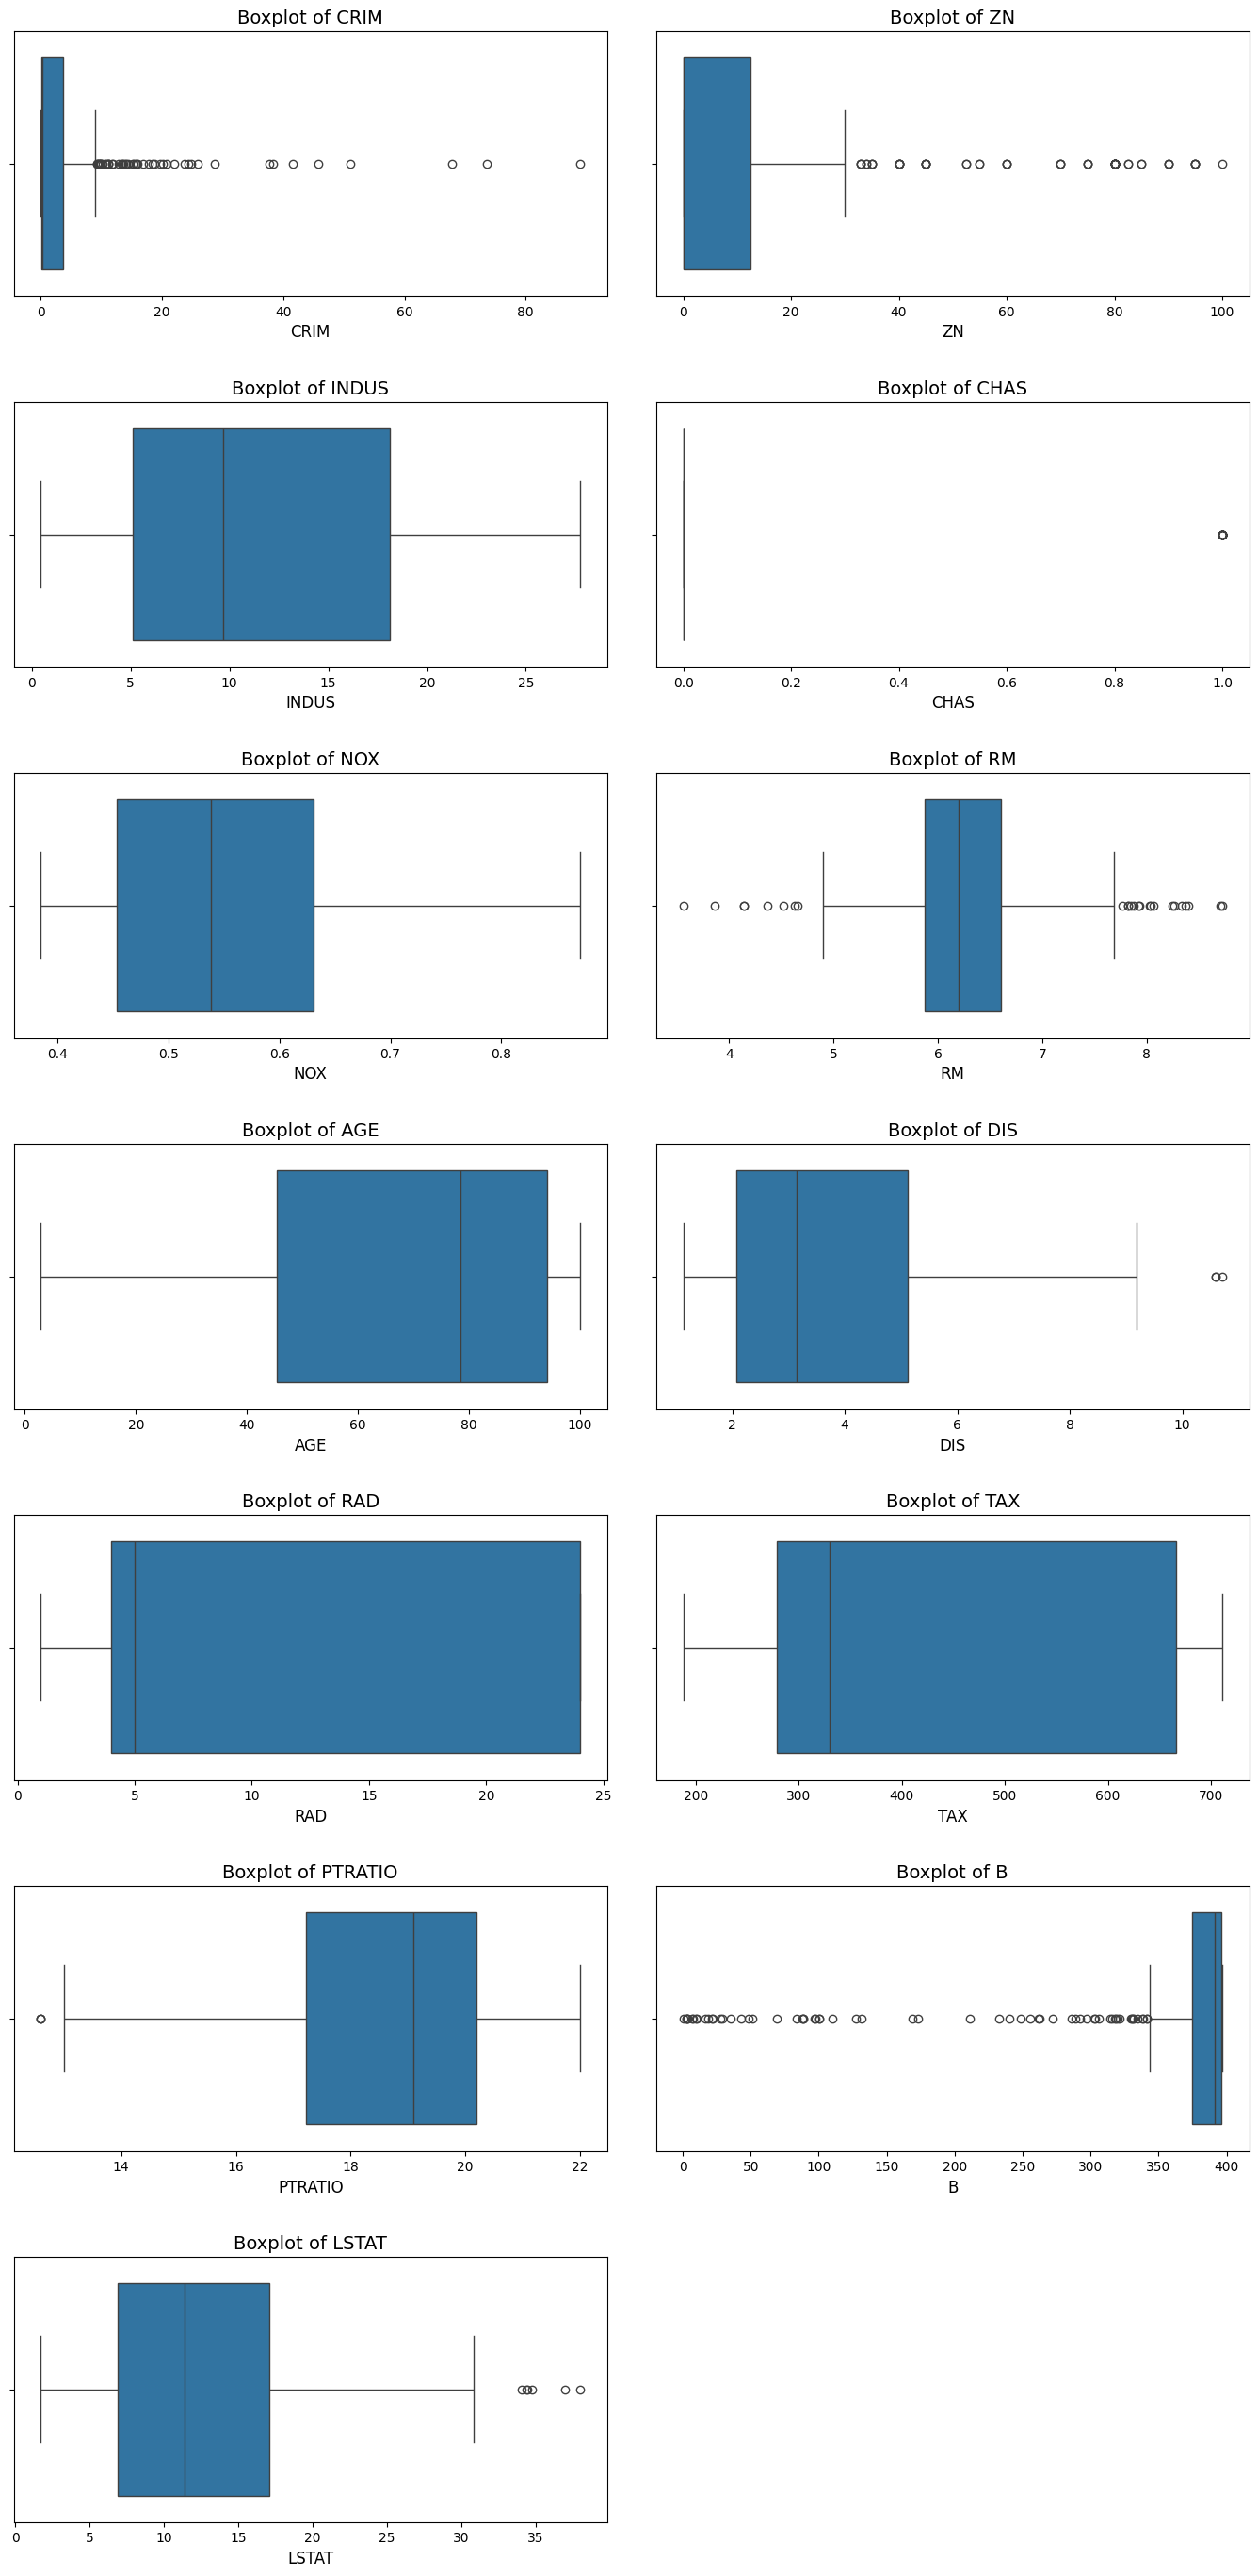

In [7]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(14, 4 * 7))
axes = axes.flatten()
for i, feat in enumerate(X_train.columns):
    ax = axes[i]
    sns.boxplot(data=X_train, x=feat, ax=ax)
    ax.set_title(f'Boxplot of {feat}', fontsize=14)
    ax.set_xlabel(feat, fontsize=12)

for i in range(len(X_train.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0)

plt.show()

In [ ]:
model = Sequential([
	Input(shape=(13,)),
	Dense(128, activation='relu'),
	Dropout(0.3),
	Dense(64, activation='relu'),
	Dropout(0.3),
	Dense(32, activation='relu'),
	Dropout(0.3),
	Dense(1)
])

In [14]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2, batch_size=32)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 508.9035 - mae: 20.6415 - val_loss: 504.4453 - val_mae: 20.2464
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 402.5256 - mae: 17.9644 - val_loss: 453.2266 - val_mae: 18.8095
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 399.4966 - mae: 17.3932 - val_loss: 416.7996 - val_mae: 17.7380
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 343.9475 - mae: 16.0182 - val_loss: 390.8546 - val_mae: 17.0167
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 338.7878 - mae: 15.6694 - val_loss: 365.1016 - val_mae: 16.3454
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 284.8321 - mae: 14.3938 - val_loss: 348.9022 - val_mae: 15.8583
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 304.1463 - mae: 14.4622 - val_loss: 334.9286 - val_mae: 15.4146
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 272.9743 - mae: 13.6413 - val_loss: 322.8756 - val_mae: 15.0162
Epoch 9/1

In [16]:
loss, mae = model.evaluate(X_test_scaled, y_test)
print(f'Mean Absolute Error: {mae * 1000:.2f}')
y_pred = model.predict(X_test_scaled).flatten()
print(f'R2: {r2_score(y_test, y_pred) * 100:.2f}%')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 41.3197 - mae: 4.2321
Mean Absolute Error: 4548.71
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
R2: 44.11%


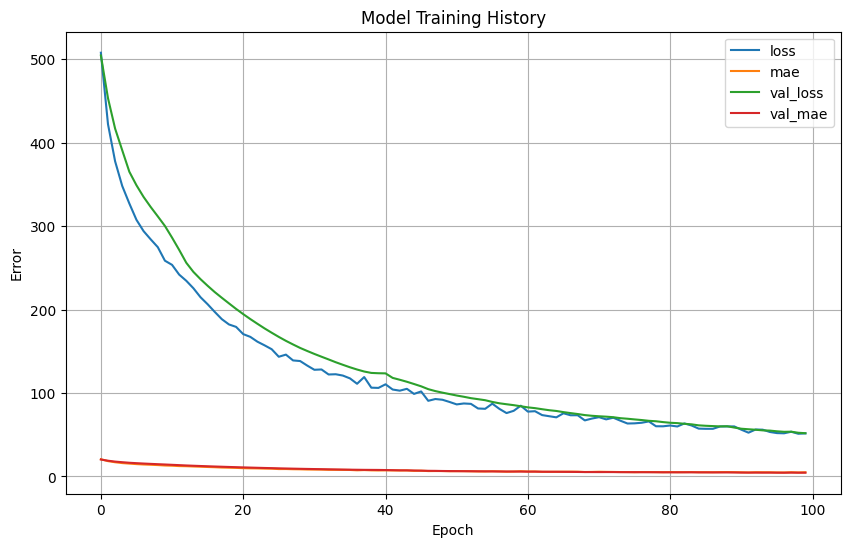

In [17]:
pd.DataFrame(model.history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title('Model Training History')
plt.ylabel('Error')
plt.xlabel('Epoch')
plt.show()